<a href="https://colab.research.google.com/github/yu-hidaka/AD-DIFFI/blob/develop/src/ad_diffi/Chapter3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AD-DIFFI: Mechanism of Structural Bias
## Chapter 3 Simulation: Decomposition of DIFFI Scores (Numerator vs. Denominator)

**Research Focus:** This simulation identifies why the Original DIFFI overestimates binary noise. By decomposing the DIFFI score into its **Numerator (Outlier CFIS)** and **Denominator (Inlier CFIS)**, we observe that binary features fail to accumulate enough "inlier counts" in the denominator, leading to an artificially inflated ratio.

## Full Implementation

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score
from collections import Counter
from math import ceil
import time

# --- Helper Functions for DIFFI Logic ---
def _get_iic(estimator, predictions, is_leaves, adjust_iic=True):
    desired_min, desired_max = 0.5, 1.0
    epsilon = 0.0
    n_nodes = estimator.tree_.node_count
    lambda_ = np.zeros(n_nodes)
    children_left = estimator.tree_.children_left
    children_right = estimator.tree_.children_right

    if predictions.shape[0] == 0: return lambda_

    node_indicator = estimator.decision_path(predictions).toarray()
    num_samples_in_node = np.sum(node_indicator, axis=0)

    for node in range(n_nodes):
        n_curr = num_samples_in_node[node]
        n_left = num_samples_in_node[children_left[node]]
        n_right = num_samples_in_node[children_right[node]]

        if n_curr <= 1 or is_leaves[node]:
            lambda_[node] = -1
        elif n_left == 0 or n_right == 0:
            lambda_[node] = epsilon
        else:
            c_min = 0.5 if n_curr % 2 == 0 else ceil(n_curr / 2) / n_curr
            c_max = (n_curr - 1) / n_curr
            tmp = max(n_left, n_right) / n_curr
            if adjust_iic and c_min != c_max:
                lambda_[node] = ((tmp - c_min) / (c_max - c_min)) * (desired_max - desired_min) + desired_min
            else:
                lambda_[node] = tmp
    return lambda_

def diffi_ib_global_logic(iforest, X, adjust_iic=True):
    num_feat = X.shape[1]
    cfi_out, cfi_in = np.zeros(num_feat), np.zeros(num_feat)
    cnt_out, cnt_in = np.zeros(num_feat, dtype=int), np.zeros(num_feat, dtype=int)

    as_full = iforest.decision_function(X)
    in_bag_samples = iforest.estimators_samples_

    for k, estimator in enumerate(iforest.estimators_):
        idx = list(in_bag_samples[k])
        X_ib, as_ib = X[idx], as_full[idx]
        X_out, X_in = X_ib[as_ib < 0], X_ib[as_ib > 0]
        if X_out.shape[0] == 0 or X_in.shape[0] == 0: continue

        n_nodes = estimator.tree_.node_count
        children_left, children_right = estimator.tree_.children_left, estimator.tree_.children_right
        feature = estimator.tree_.feature
        node_depth = np.zeros(n_nodes, dtype=int)
        is_leaves = np.zeros(n_nodes, dtype=bool)

        stack = [(0, -1)]
        while stack:
            node_id, p_depth = stack.pop()
            node_depth[node_id] = p_depth + 1
            if children_left[node_id] != children_right[node_id]:
                stack.append((children_left[node_id], p_depth + 1))
                stack.append((children_right[node_id], p_depth + 1))
            else: is_leaves[node_id] = True

        def process_cfis(data_subset, cfi_arr, cnt_arr, is_outlier):
            lambdas = _get_iic(estimator, data_subset, is_leaves, adjust_iic)
            indicator = estimator.decision_path(data_subset).toarray()
            for i in range(len(data_subset)):
                path = np.where(indicator[i] == 1)[0]
                depth = node_depth[path[-1]]
                for node in path:
                    f_idx = feature[node]
                    if f_idx >= 0 and lambdas[node] != -1:
                        cfi_arr[f_idx] += (1 / depth) * lambdas[node]
                        cnt_arr[f_idx] += 1

        process_cfis(X_out, cfi_out, cnt_out, True)
        process_cfis(X_in, cfi_in, cnt_in, False)

    fi_out = np.where(cnt_out > 0, cfi_out / cnt_out, 0)
    fi_in = np.where(cnt_in > 0, cfi_in / cnt_in, 0)
    fi_final = np.divide(fi_out, fi_in, out=np.zeros_like(fi_out), where=fi_in != 0)
    return fi_final, cfi_out, cfi_in

# --- Simulation Runner ---
def run_thesis_bias_test(n_iter=100):
    rng = np.random.default_rng(42)
    n_total, contamination = 1000, 0.05

    # Data Generation (Noise only to identify structural bias)
    df = pd.DataFrame({
        'F_binary': rng.binomial(1, 0.5, n_total),
        'F_continuous': rng.uniform(0, 10, n_total),
        'F_noise': rng.uniform(0, 10, n_total),
        'Y': rng.choice([0, 1], n_total, p=[1-contamination, contamination])
    })

    X, y = df[['F_binary', 'F_continuous', 'F_noise']], df['Y'].values
    fi_list, cfi_out_list, cfi_in_list = [], [], []

    for k in range(n_iter):
        model = IsolationForest(n_estimators=100, contamination=contamination, random_state=k).fit(X.values)
        fi, cout, cin = diffi_ib_global_logic(model, X.values)
        fi_list.append(fi); cfi_out_list.append(cout); cfi_in_list.append(cin)

    return np.vstack(fi_list), np.vstack(cfi_out_list), np.vstack(cfi_in_list), X.columns

## Plotting Thesis Figures

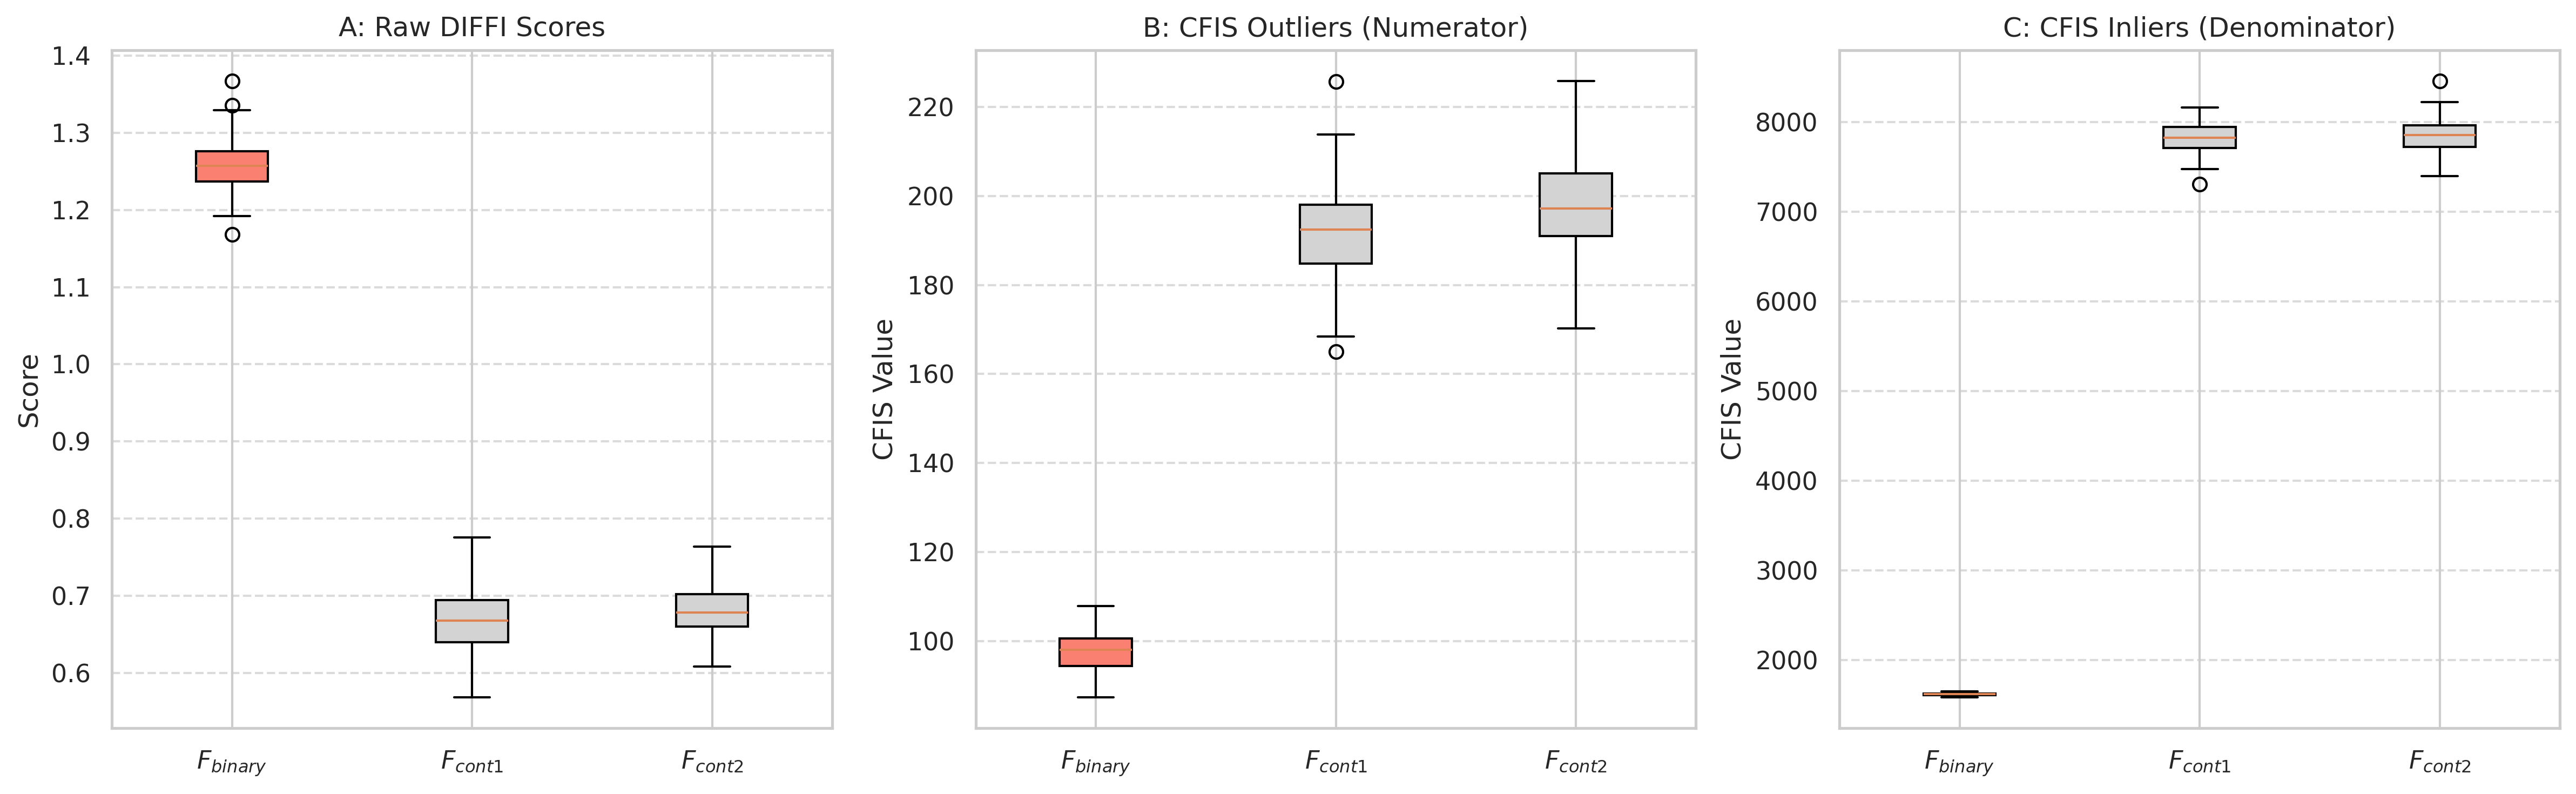

In [9]:
# Execution
fi_matrix, cout_matrix, cin_matrix, feat_names = run_thesis_bias_test(100)

# Visualization
plt.rcParams.update({'font.size': 10, 'figure.figsize': (16, 5)})
fig, axes = plt.subplots(1, 3, dpi=300)

titles = ['A: Raw DIFFI Scores', 'B: CFIS Outliers (Numerator)', 'C: CFIS Inliers (Denominator)']
data_mats = [fi_matrix, cout_matrix, cin_matrix]
ylabels = ['Score', 'CFIS Value', 'CFIS Value']
labels_math = [r'$F_{binary}$', r'$F_{cont1}$', r'$F_{cont2}$']

for i, ax in enumerate(axes):
    bp = ax.boxplot(data_mats[i], patch_artist=True, labels=labels_math)
    bp['boxes'][0].set_facecolor('salmon') # Highlight Binary
    for box in bp['boxes'][1:]: box.set_facecolor('lightgray')
    ax.set_title(titles[i])
    ax.set_ylabel(ylabels[i])
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 3.4. Interpretation of Simulation Results

The three panels above decompose the **Structural Bias** inherent in the Original DIFFI:

1.  **Panel B (Outliers/Numerator)**: Notice that $F_{binary}$ and $F_{continuous}$ show relatively similar accumulation patterns for outliers. This suggests that at shallow depths, both feature types can be selected as splitting criteria.
2.  **Panel C (Inliers/Denominator)**: This is the **root cause of the bias**. Continuous features ($F_{cont}$) accumulate significantly higher CFIS values in the denominator because they can be split multiple times across various depths in a single tree. In contrast, $F_{binary}$ can only be split once, leading to a much smaller denominator.
3.  **Panel A (Final Ratio)**: Because DIFFI is calculated as `Numerator / Denominator`, the smaller denominator for $F_{binary}$ causes its final score to be **artificially inflated**.

**Conclusion**: The Original DIFFI overestimates binary features not because they are "more abnormal," but because they are "less present" in the normal (inlier) path accumulation. This necessitates the **Standardization (Z-score)** and **RSO Constraint** proposed in the subsequent chapters.

## Statistical Summary for Thesis

In [10]:
# Calculate mean scores for the thesis text
mean_scores = np.mean(fi_matrix, axis=0)
mean_inliers = np.mean(cin_matrix, axis=0)

print("--- Quantitative Analysis for Thesis ---")
print(f"Average DIFFI Score (Binary): {mean_scores[0]:.4f}")
print(f"Average DIFFI Score (Cont 1): {mean_scores[1]:.4f}")
print(f"Bias Ratio (Bin/Cont): {mean_scores[0] / mean_scores[1]:.2f}x")
print("-" * 40)
print(f"Denominator Accumulation (Binary): {mean_inliers[0]:.4f}")
print(f"Denominator Accumulation (Cont 1): {mean_inliers[1]:.4f}")
print(f"Accumulation Gap: {mean_inliers[1] / mean_inliers[0]:.2f}x more accumulation in continuous features.")

if mean_scores[0] > mean_scores[1]:
    print("\n[Confirmed] Structural bias towards binary features is statistically present.")

--- Quantitative Analysis for Thesis ---
Average DIFFI Score (Binary): 1.2566
Average DIFFI Score (Cont 1): 0.6688
Bias Ratio (Bin/Cont): 1.88x
----------------------------------------
Denominator Accumulation (Binary): 1618.3608
Denominator Accumulation (Cont 1): 7820.6694
Accumulation Gap: 4.83x more accumulation in continuous features.

[Confirmed] Structural bias towards binary features is statistically present.
